# Análise Exploratória e Balanceamento dos Datasets Adult e Dry Bean

Este notebook realiza uma análise exploratória dos datasets Adult e Dry Bean, mostrando informações iniciais, distribuição das classes, balanceamento por oversampling e codificação das variáveis categóricas. Ao final, os datasets processados são salvos nas pastas correspondentes.

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
import os

## 2. Análise do Dataset Adult

In [2]:
# Carrega o dataset Adult
adult_path = 'data/AdultDataset/adult.data'
adult_df = pd.read_csv(adult_path, header=None, na_values=' ?', skipinitialspace=True)
adult_df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
print('Adult shape:', adult_df.shape)
print('Adult columns:', adult_df.columns.tolist())
print('Adult target unique values:', adult_df['income'].unique())
print('Adult missing values:', adult_df.isnull().sum().sum())

Adult shape: (32561, 15)
Adult columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
Adult target unique values: ['<=50K' '>50K']
Adult missing values: 0


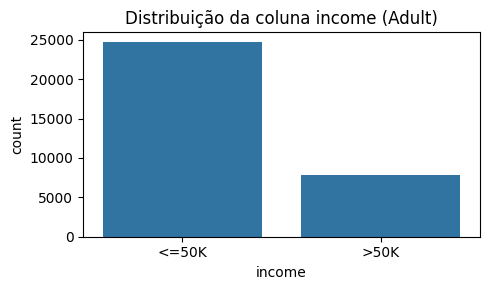

In [3]:
# Histograma de frequência da variável alvo
plt.figure(figsize=(5,3))
sns.countplot(x=adult_df['income'])
plt.title('Distribuição da coluna income (Adult)')
plt.tight_layout()
os.makedirs('img', exist_ok=True)
plt.savefig('img/adult_income_hist_before_balance.png')
plt.show()

## 3. Balanceamento do Dataset Adult

In [4]:
# Remove valores ausentes
adult_df = adult_df.dropna().copy()
# Cria coluna binária
adult_df['income_bin'] = adult_df['income'].apply(lambda v: 1 if v.strip() == '>50K' else 0)
df_majority = adult_df[adult_df['income_bin'] == 0]
df_minority = adult_df[adult_df['income_bin'] == 1]
n_majority = len(df_majority)
df_minority_upsampled = resample(df_minority, replace=True, n_samples=n_majority, random_state=42)
adult_df_bal = pd.concat([df_majority, df_minority_upsampled])
adult_df_bal = adult_df_bal.sample(frac=1, random_state=42).reset_index(drop=True)
print('Adult balanceado shape:', adult_df_bal.shape)
print('Distribuição após balanceamento:')
print(adult_df_bal['income_bin'].value_counts())

Adult balanceado shape: (49440, 16)
Distribuição após balanceamento:
income_bin
1    24720
0    24720
Name: count, dtype: int64


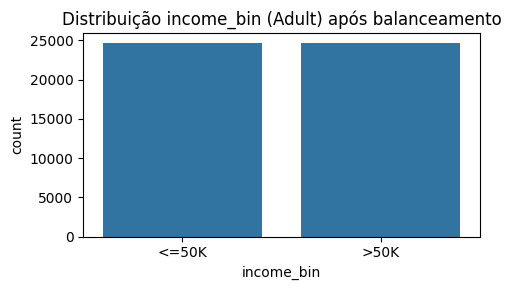

In [5]:
# Histograma após balanceamento
plt.figure(figsize=(5,3))
sns.countplot(x=adult_df_bal['income_bin'])
plt.title('Distribuição income_bin (Adult) após balanceamento')
plt.xticks([0,1],["<=50K",">50K"])
plt.tight_layout()
os.makedirs('img', exist_ok=True)
plt.savefig('img/adult_income_hist_after_balance.png')
plt.show()

## 4. Codificação das Variáveis Categóricas (Adult)

In [6]:
adult_df_bal_encoded = adult_df_bal.copy()
for col in adult_df_bal_encoded.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_bal_encoded[col] = LabelEncoder().fit_transform(adult_df_bal_encoded[col].astype(str))
print('Adult balanceado codificado shape:', adult_df_bal_encoded.shape)

Adult balanceado codificado shape: (49440, 16)


In [7]:
# Salva o dataset processado na pasta do Adult
os.makedirs('data/AdultDataset', exist_ok=True)
adult_df_bal_encoded.to_csv('data/AdultDataset/adult_balanced_encoded.csv', index=False)

## 5. Análise do Dataset Dry Bean

In [8]:
# Carrega o dataset Dry Bean
drybean_path = 'data/DryBeanDataset/Dry_Bean_Dataset.xlsx'
bean_df = pd.read_excel(drybean_path)
print('Dry Bean shape:', bean_df.shape)
print('Dry Bean columns:', bean_df.columns.tolist())
print('Dry Bean target unique values:', bean_df['Class'].unique())
print('Dry Bean missing values:', bean_df.isnull().sum().sum())

Dry Bean shape: (13611, 17)
Dry Bean columns: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']
Dry Bean target unique values: ['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']
Dry Bean missing values: 0


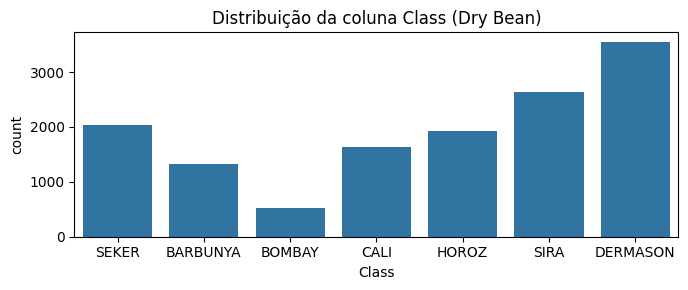

In [9]:
# Histograma de frequência da variável alvo
plt.figure(figsize=(7,3))
sns.countplot(x=bean_df['Class'])
plt.title('Distribuição da coluna Class (Dry Bean)')
plt.tight_layout()
os.makedirs('img', exist_ok=True)
plt.savefig('img/drybean_class_hist_before_balance.png')
plt.show()

## 6. Balanceamento do Dataset Dry Bean

In [10]:
# Remove valores ausentes
bean_df = bean_df.dropna().copy()
# Identifica a classe minoritária
class_counts = bean_df['Class'].value_counts()
min_class = class_counts.idxmin()
max_count = class_counts.max()
dfs = []
for c in class_counts.index:
    df_c = bean_df[bean_df['Class'] == c]
    if len(df_c) < max_count:
        df_c = resample(df_c, replace=True, n_samples=max_count, random_state=42)
    dfs.append(df_c)
bean_df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print('Dry Bean balanceado shape:', bean_df_bal.shape)
print('Distribuição após balanceamento:')
print(bean_df_bal['Class'].value_counts())

Dry Bean balanceado shape: (24822, 17)
Distribuição após balanceamento:
Class
SIRA        3546
HOROZ       3546
SEKER       3546
BARBUNYA    3546
BOMBAY      3546
DERMASON    3546
CALI        3546
Name: count, dtype: int64


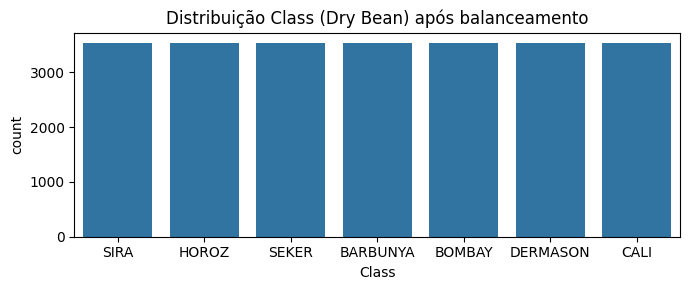

In [11]:
# Histograma após balanceamento
plt.figure(figsize=(7,3))
sns.countplot(x=bean_df_bal['Class'])
plt.title('Distribuição Class (Dry Bean) após balanceamento')
plt.tight_layout()
os.makedirs('img', exist_ok=True)
plt.savefig('img/drybean_class_hist_after_balance.png')
plt.show()

## 7. Codificação das Variáveis Categóricas (Dry Bean)

In [12]:
bean_df_bal_encoded = bean_df_bal.copy()
for col in bean_df_bal_encoded.select_dtypes(include='object').columns:
    bean_df_bal_encoded[col] = LabelEncoder().fit_transform(bean_df_bal_encoded[col].astype(str))
print('Dry Bean balanceado codificado shape:', bean_df_bal_encoded.shape)

Dry Bean balanceado codificado shape: (24822, 17)


In [13]:
# Salva o dataset processado na pasta do Dry Bean
os.makedirs('data/DryBeanDataset', exist_ok=True)
bean_df_bal_encoded.to_csv('data/DryBeanDataset/drybean_balanced_encoded.csv', index=False)